# 🚀 SpaceX Falcon 9 Landing Prediction

In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Importing Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Module 1 — Data Collection & Wrangling

In [4]:
#Loading the Dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


In [5]:
#Checking Missing Values
df.isnull().sum()/len(df)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [6]:
df.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
dtype: object

#### Exploring Key Columns

In [7]:
df['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [9]:
df['Orbit'].value_counts()

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
HEO       1
ES-L1     1
SO        1
GEO       1
Name: count, dtype: int64

In [10]:
df['Outcome'].value_counts()

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64

In [11]:
landing_outcomes=df['Outcome'].value_counts()

In [12]:
for i, outcome in enumerate(landing_outcomes.keys()):
    print(i, outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


In [13]:
bad_outcome = set(landing_outcomes.keys()[[1,3,5,6,7]])
bad_outcome

{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

In [14]:
landing_class = [0 if outcome in bad_outcome else 1 for outcome in df['Outcome']]

In [15]:
#Creating Target Variable (Class)
df['Class']=landing_class
df[['Class']].head(8)

,Class
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,1


In [16]:
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [17]:
df["Class"].mean()

np.float64(0.6666666666666666)

## Module 2 — SQL

In [16]:
#Setting up Database
!pip install sqlalchemy


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!pip install ipython-sql
!pip install ipython-sql prettytable



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [20]:
import csv, sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect('my_data1.db')
cur = con.cursor()

In [21]:
!pip install -q pandas


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
%sql sqlite:///my_data1.db

In [24]:
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method='multi')

101

In [25]:
%sql DROP TABLE IF EXISTS SPACETABLEX;

 * sqlite:///my_data1.db
Done.


[]

In [26]:
%sql create table SPACETABLEX as select * from SPACEXTBL where DATE IS NOT NULL

 * sqlite:///my_data1.db
Done.


[]

In [27]:
%sql SELECT DISTINCT "Launch_Site" from SPACEXTBL

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


In [28]:
%sql SELECT * from SPACEXTBL where "Launch_Site" like 'CCA%'

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt
2013-12-03,22:41:00,F9 v1.1,CCAFS LC-40,SES-8,3170,GTO,SES,Success,No attempt
2014-01-06,22:06:00,F9 v1.1,CCAFS LC-40,Thaicom 6,3325,GTO,Thaicom,Success,No attempt
2014-04-18,19:25:00,F9 v1.1,CCAFS LC-40,SpaceX CRS-3,2296,LEO (ISS),NASA (CRS),Success,Controlled (ocean)
2014-07-14,15:15:00,F9 v1.1,CCAFS LC-40,OG2 Mission 1 6 Orbcomm-OG2 satellites,1316,LEO,Orbcomm,Success,Controlled (ocean)
2014-08-05,8:00:00,F9 v1.1,CCAFS LC-40,AsiaSat 8,4535,GTO,AsiaSat,Success,No attempt


In [29]:
%sql SELECT sum("Payload_Mass__kg_") as total_payload_mass from SPACEXTBL where "Customer" = 'NASA (CRS)';

 * sqlite:///my_data1.db
Done.


total_payload_mass
45596


In [30]:
%%sql
SELECT * FROM SPACEXTBL LIMIT 1;

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)


In [31]:
%sql select avg("Payload_Mass__kg_") AS avg_payload_mass from SPACEXTBL where "Booster_Version" = 'F9 v1.1';

 * sqlite:///my_data1.db
Done.


avg_payload_mass
2928.4


In [32]:
%sql select MIN("Date") as first_success_date from SPACEXTBL where "Landing_Outcome" = 'Success(ground pad)';

 * sqlite:///my_data1.db
Done.


first_success_date
None


In [33]:
%sql select "Booster_Version" from SPACEXTBL where "Landing_Outcome" = 'Success(drone ship)' and "Payload_Mass__kg_">4000 and "Payload_Mass__kg_"<6000;

 * sqlite:///my_data1.db
Done.


Booster_Version


In [34]:
%%sql
SELECT "Mission_Outcome", COUNT(*) AS count
FROM SPACEXTBL
GROUP BY "Mission_Outcome";

 * sqlite:///my_data1.db
Done.


Mission_Outcome,count
Failure (in flight),1
Success,98
Success,1
Success (payload status unclear),1


In [35]:
%sql select "Booster_Version" from SPACEXTBL where "Payload_Mass__kg_" = (select max("Payload_Mass__kg_") from SPACEXTBL);

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


In [36]:
%%sql
SELECT 
    SUBSTR("Date", 6, 2) AS month,
    "Landing_Outcome",
    "Booster_Version",
    "Launch_Site"
FROM SPACEXTBL
WHERE SUBSTR("Date", 1, 4) = '2015'
  AND "Landing_Outcome" LIKE 'Failure (drone ship)%';

 * sqlite:///my_data1.db
Done.


month,Landing_Outcome,Booster_Version,Launch_Site
01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


In [37]:
%%sql select "Landing_Outcome", COUNT(*) As outcome_count from SPACEXTBL where "Date" BETWEEN '2010-06-04' and '2017-03-20' 
GROUP BY "Landing_Outcome"
ORDER BY outcome_count DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,outcome_count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


## Module 3 — EDA

In [18]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


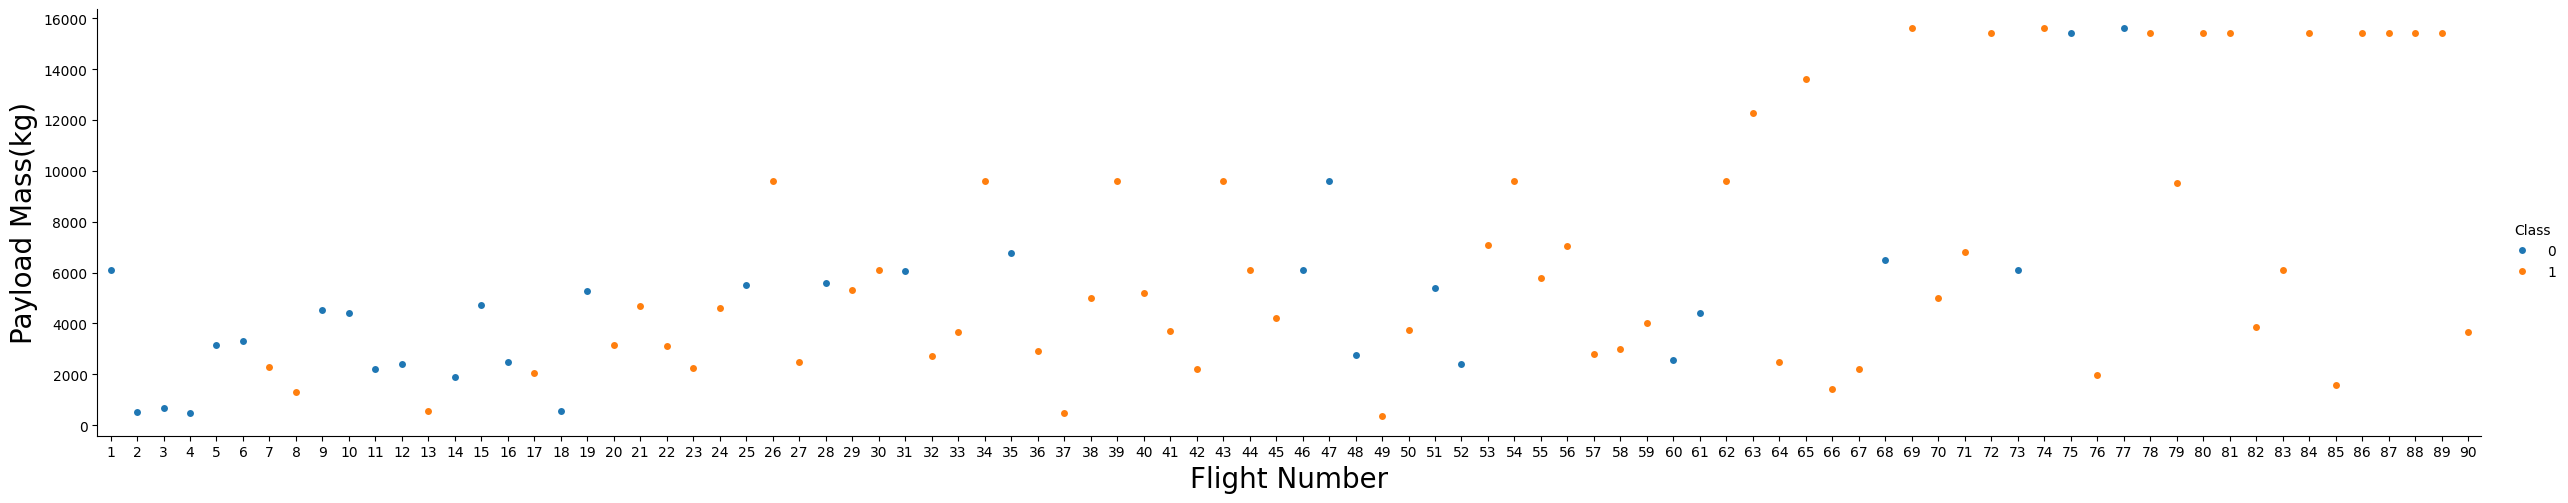

In [19]:
# Plotting Flight Number vs Payload Mass colored by landing Class
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=data, aspect=5)
plt.xlabel("Flight Number", fontsize=20 )
plt.ylabel("Payload Mass(kg)", fontsize=20)
plt.show()

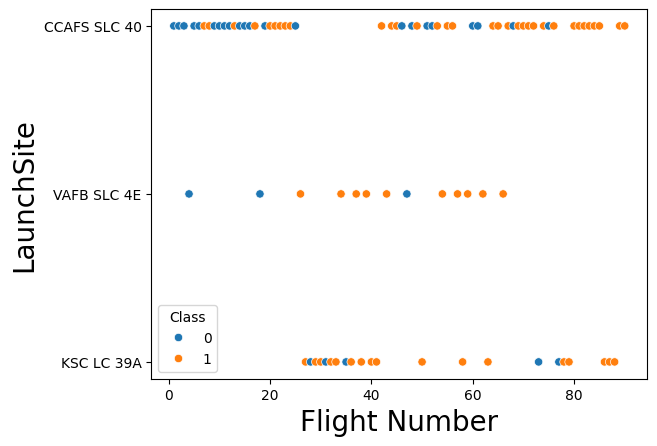

In [20]:
# Plotting a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.scatterplot(x="FlightNumber", y="LaunchSite", hue="Class", data=data)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show()

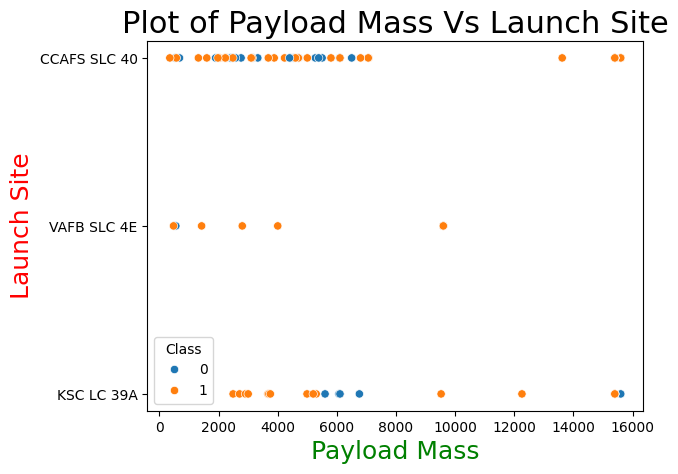

In [21]:
# Plotting a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.scatterplot(x="PayloadMass", y="LaunchSite", hue="Class", data=data)
plt.xlabel("Payload Mass", fontsize=18, color='green')
plt.ylabel("Launch Site", fontsize=18, color='red')
plt.title("Plot of Payload Mass Vs Launch Site", fontsize=22)
plt.show()

In [22]:
orbit_success = data.groupby("Orbit")["Class"].mean().reset_index()

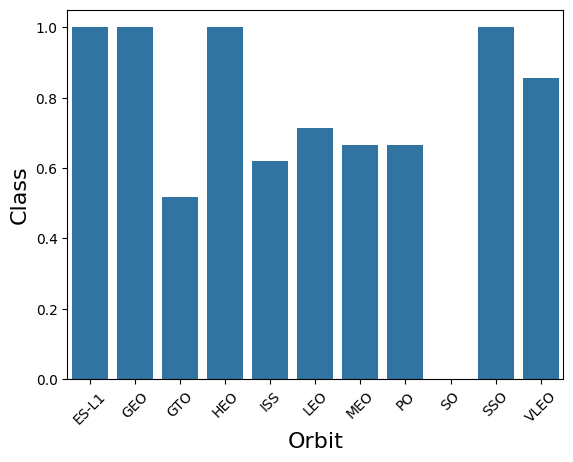

In [23]:
#Visualization of  the relationship between success rate of each orbit type
sns.barplot(x="Orbit", y="Class", data=orbit_success)
plt.xlabel("Orbit", fontsize=16)
plt.ylabel("Class", fontsize=16)
plt.xticks(rotation=45)
plt.show()

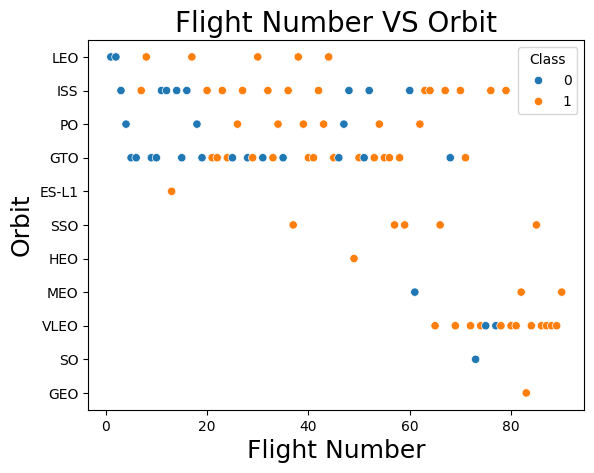

In [46]:
# Plotting a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.scatterplot(x="FlightNumber", y="Orbit", hue="Class", data=data)
plt.xlabel("Flight Number", fontsize=18)
plt.ylabel("Orbit", fontsize=18)
plt.title("Flight Number VS Orbit", fontsize=20)
plt.show()

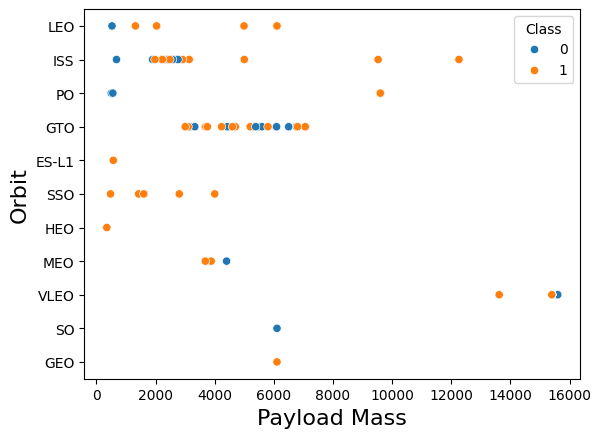

In [47]:
# Plotting a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
sns.scatterplot(x="PayloadMass", y="Orbit", hue="Class", data=data)
plt.xlabel("Payload Mass", fontsize=16)
plt.ylabel("Orbit", fontsize=16)
plt.show()

In [24]:
print(data["Date"].head())  

0    2010-06-04
1    2012-05-22
2    2013-03-01
3    2013-09-29
4    2013-12-03
Name: Date, dtype: object


In [26]:
data["Year"] = pd.to_datetime(data["Date"]).dt.year

In [27]:
yearly_success = data.groupby("Year")["Class"].mean().reset_index()
print(yearly_success.shape)  
print(yearly_success)

(10, 2)
   Year     Class
0  2010  0.000000
1  2012  0.000000
2  2013  0.000000
3  2014  0.333333
4  2015  0.333333
5  2016  0.625000
6  2017  0.833333
7  2018  0.611111
8  2019  0.900000
9  2020  0.842105


In [56]:
print(data["Date"].head(10))
print(type(data["Date"].iloc[0]))
print(data["Year"].head(10))
print(data["Year"].unique())
print(yearly_success.shape)
print(yearly_success.head(20))

0    2010-06-04
1    2012-05-22
2    2013-03-01
3    2013-09-29
4    2013-12-03
5    2014-01-06
6    2014-04-18
7    2014-07-14
8    2014-08-05
9    2014-09-07
Name: Date, dtype: object
<class 'str'>
0    2010-06-04
1    2012-05-22
2    2013-03-01
3    2013-09-29
4    2013-12-03
5    2014-01-06
6    2014-04-18
7    2014-07-14
8    2014-08-05
9    2014-09-07
Name: Year, dtype: object
['2010-06-04' '2012-05-22' '2013-03-01' '2013-09-29' '2013-12-03'
 '2014-01-06' '2014-04-18' '2014-07-14' '2014-08-05' '2014-09-07'
 '2014-09-21' '2015-01-10' '2015-02-11' '2015-04-14' '2015-04-27'
 '2015-06-28' '2015-12-22' '2016-01-17' '2016-03-04' '2016-04-08'
 '2016-05-06' '2016-05-27' '2016-07-18' '2016-08-14' '2016-09-01'
 '2017-01-14' '2017-02-19' '2017-03-16' '2017-03-30' '2017-05-01'
 '2017-05-15' '2017-06-03' '2017-06-23' '2017-06-25' '2017-07-05'
 '2017-08-14' '2017-08-24' '2017-09-07' '2017-10-09' '2017-10-11'
 '2017-10-30' '2017-12-15' '2017-12-23' '2018-01-08' '2018-01-31'
 '2018-03-06' '2018-

['2010' '2012' '2013' '2014' '2015' '2016' '2017' '2018' '2019' '2020']
   Year     Class
0  2010  0.000000
1  2012  0.000000
2  2013  0.000000
3  2014  0.333333
4  2015  0.333333
5  2016  0.625000
6  2017  0.833333
7  2018  0.611111
8  2019  0.900000
9  2020  0.842105


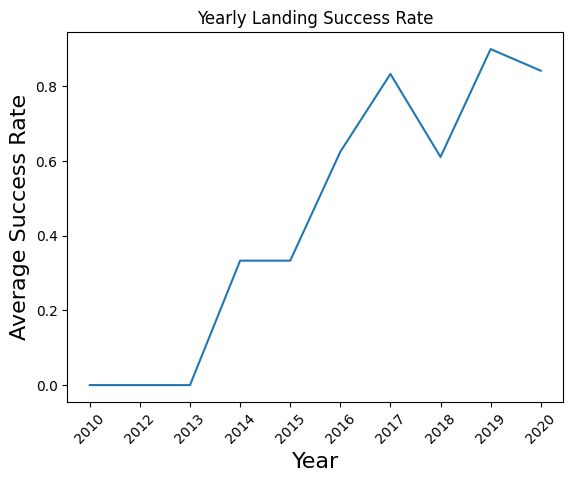

In [57]:
#Line Chart showing Yearly Landing Success Rate
data["Year"] = data["Date"].apply(lambda x: x.split("-")[0])

print(data["Year"].unique())

yearly_success = data.groupby("Year")["Class"].mean().reset_index()
print(yearly_success)

sns.lineplot(x="Year", y="Class", data=yearly_success)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Average Success Rate", fontsize=16)
plt.title("Yearly Landing Success Rate")
plt.xticks(rotation=45)
plt.show()

In [58]:
#Feature Selection & One-Hot Encoding
features = data[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [59]:
features_one_hot = pd.get_dummies(
    features,
    columns=['Orbit','LaunchSite', 'LandingPad', 'Serial']
)
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [60]:
features_one_hot = features_one_hot.astype("float64")

In [61]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

## Module 4 — Interactive Visual Analytics

In [62]:
!pip install folium
import folium


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from folium.plugins import MarkerCluster
from folium.plugins import MousePosition
from folium.features import DivIcon

In [64]:
spacex_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv")
spacex_df.head()

,Flight Number,Date,Time (UTC),Booster Version,Launch Site,Payload,Payload Mass (kg),Orbit,Customer,Landing Outcome,class,Lat,Long
0,1,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0.0,LEO,SpaceX,Failure (parachute),0,28.562302,-80.577356
1,2,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel o...",0.0,LEO (ISS),NASA (COTS) NRO,Failure (parachute),0,28.562302,-80.577356
2,3,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2+,525.0,LEO (ISS),NASA (COTS),No attempt,0,28.562302,-80.577356
3,4,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356
4,5,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356


In [65]:
spacex_df = spacex_df[['Launch Site','Lat','Long','class']]

In [66]:
launch_site_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_site_df = launch_site_df[['Launch Site', 'Lat', 'Long']]
launch_site_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [67]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

In [79]:
print(spacex_df.columns.tolist())

['Launch Site', 'Lat', 'Long', 'class']


In [82]:
print(spacex_df['class'].value_counts())
print(spacex_df['class'].dtype)

class
0    32
1    24
Name: count, dtype: int64
int64


In [86]:
# Marking all launch Sites on the Map using Folium
import folium
import numpy as np

np.random.seed(42)

coords = {
    'CCAFS LC-40':  (28.562302, -80.577356),
    'CCAFS SLC-40': (28.562302, -80.577356),
    'KSC LC-39A':   (28.573255, -80.646895),
    'VAFB SLC-4E':  (34.632834, -120.610745)
}

spacex_df['Lat']  = spacex_df['Launch Site'].map(lambda x: coords[x][0])
spacex_df['Long'] = spacex_df['Launch Site'].map(lambda x: coords[x][1])

site_map = folium.Map(location=[32, -100], zoom_start=4)

for index, row in spacex_df.iterrows():
    if row['class'] == 1:
        # Success → green star marker
        icon = folium.Icon(color='green', icon='star')
    else:
        # Failure → red X marker  
        icon = folium.Icon(color='red', icon='remove')
    
    folium.Marker(
        location=[
            row['Lat'] + np.random.uniform(-0.15, 0.15),
            row['Long'] + np.random.uniform(-0.15, 0.15)
        ],
        icon=icon,
        popup=f"{row['Launch Site']} | {'Success' if row['class']==1 else 'Failed'}"
    ).add_to(site_map)

site_map

In [87]:
print(spacex_df['Launch Site'].unique())
print(spacex_df[['Launch Site', 'Lat', 'Long']].drop_duplicates())

['CCAFS LC-40' 'VAFB SLC-4E' 'KSC LC-39A' 'CCAFS SLC-40']
     Launch Site        Lat        Long
0    CCAFS LC-40  28.562302  -80.577356
26   VAFB SLC-4E  34.632834 -120.610745
36    KSC LC-39A  28.573255  -80.646895
49  CCAFS SLC-40  28.562302  -80.577356


In [73]:
print(spacex_df[['Lat', 'Long', 'class']].to_string())

          Lat        Long  class
0   28.562302  -80.577356      0
1   28.562302  -80.577356      0
2   28.562302  -80.577356      0
3   28.562302  -80.577356      0
4   28.562302  -80.577356      0
5   28.562302  -80.577356      0
6   28.562302  -80.577356      0
7   28.562302  -80.577356      0
8   28.562302  -80.577356      0
9   28.562302  -80.577356      0
10  28.562302  -80.577356      0
11  28.562302  -80.577356      0
12  28.562302  -80.577356      0
13  28.562302  -80.577356      0
14  28.562302  -80.577356      0
15  28.562302  -80.577356      0
16  28.562302  -80.577356      0
17  28.562302  -80.577356      1
18  28.562302  -80.577356      1
19  28.562302  -80.577356      0
20  28.562302  -80.577356      1
21  28.562302  -80.577356      1
22  28.562302  -80.577356      1
23  28.562302  -80.577356      0
24  28.562302  -80.577356      1
25  28.562302  -80.577356      1
26  34.632834 -120.610745      0
27  34.632834 -120.610745      0
28  34.632834 -120.610745      1
29  34.632

In [69]:
print(spacex_df.shape)
print(spacex_df[['Launch Site', 'Lat', 'Long', 'class']].head(10))
print(spacex_df['class'].value_counts())

(56, 4)
   Launch Site        Lat       Long  class
0  CCAFS LC-40  28.562302 -80.577356      0
1  CCAFS LC-40  28.562302 -80.577356      0
2  CCAFS LC-40  28.562302 -80.577356      0
3  CCAFS LC-40  28.562302 -80.577356      0
4  CCAFS LC-40  28.562302 -80.577356      0
5  CCAFS LC-40  28.562302 -80.577356      0
6  CCAFS LC-40  28.562302 -80.577356      0
7  CCAFS LC-40  28.562302 -80.577356      0
8  CCAFS LC-40  28.562302 -80.577356      0
9  CCAFS LC-40  28.562302 -80.577356      0
class
0    32
1    24
Name: count, dtype: int64


In [64]:
df[df['Landing_Outcome'] == 'Success (drone ship)'].shape[0]

14

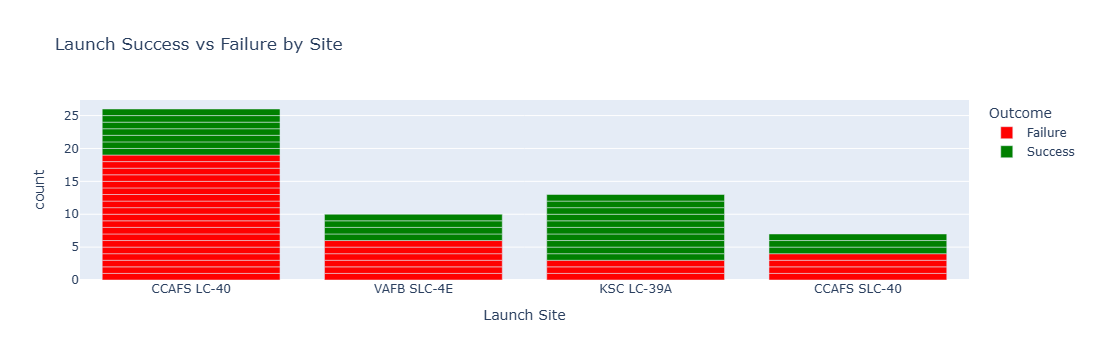

In [73]:
# Bar Chart showing Success vs Failure by Site
import plotly.express as px

spacex_df['outcome'] = spacex_df['class'].map({0: 'Failure', 1: 'Success'})

fig = px.bar(spacex_df,
             x='Launch Site',
             color='outcome',
             title='Launch Success vs Failure by Site',
             labels={'outcome': 'Outcome'},
             color_discrete_map={
                 'Failure': 'red',
                 'Success': 'green'
             })

fig.show()

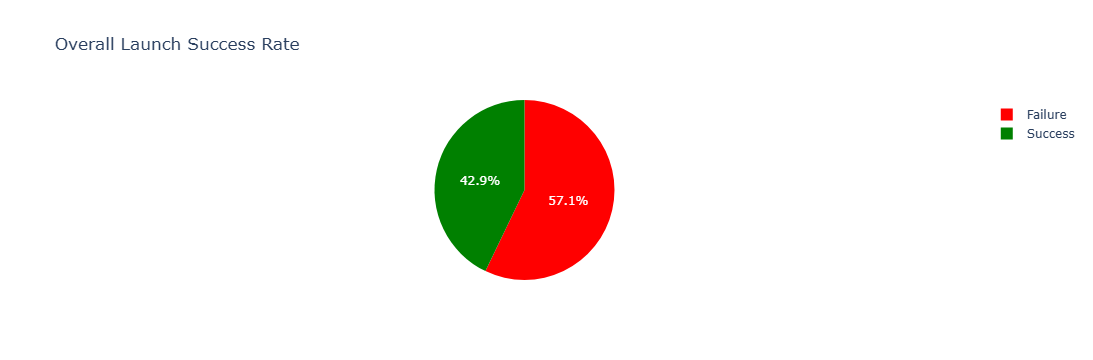

In [74]:
# Pie Chart showing overall Success and Failure Rates
fig2 = px.pie(spacex_df,
              names='outcome',
              title='Overall Launch Success Rate',
              color='outcome',
              color_discrete_map={
                  'Failure': 'red',
                  'Success': 'green'
              })

fig2.show()

In [88]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Module 5 — Machine Learning Prediction

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [29]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); 
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [30]:
data1 = pd.read_csv ("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data1.shape

(90, 18)

In [31]:
data2 = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
data2.shape

(90, 83)

In [35]:
print(data2.columns.tolist()) 

if 'Class' in data2.columns:
    X = data2.drop('Class', axis=1)
else:
    X = data2

Y = data1['Class']

print(X.shape)  
print(Y.shape)  

['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS', 'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO', 'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7', 'LandingPad_5e9e3032383ecb554034e7c9', 'LandingPad_5e9e3032383ecb6bb234e7ca', 'LandingPad_5e9e3032383ecb761634e7cb', 'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005', 'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005', 'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010', 'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015', 'Serial_B1016', 'Serial_B1017', 'Serial_B1018', 'Serial_B1019', 'Serial_B1020', 'Serial_B1021', 'Serial_B1022', 'Serial_B1023', 'Serial_B1025', 'Serial_B1026', 'Serial_B1028', 'Serial_B1029', 'Serial_B1030', 'Serial_B1031', 'Serial_B1032', 'Serial_B1034', 'Serial_B1035', 'Serial_B1036', 'Ser

In [37]:
#Scaling
Y = data1['Class']

print(X.shape)  
print(Y.shape)  

# Training test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)
print("Test size:", len(Y_test))  

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

(90, 83)
(90,)
Test size: 18


In [34]:
parameters = {'C': [0.01, 0.1, 1, 10, 100],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

print("Tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("Accuracy:", logreg_cv.best_score_)

C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

Tuned hyperparameters (best parameters): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.8464285714285713


C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Rishika Sinha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

LR Test Accuracy: 0.8333333333333334


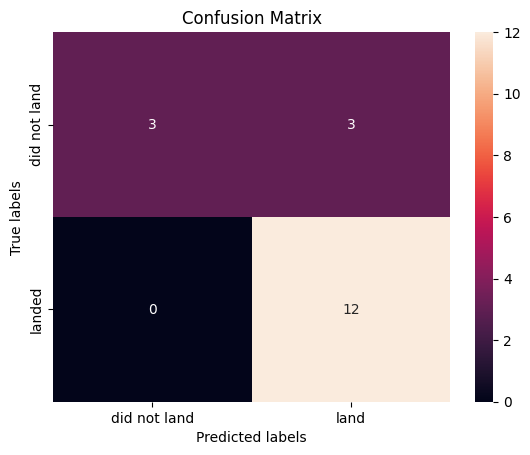

In [101]:
# Predicting and evaluating Logistic Regression on test data
from sklearn.metrics import accuracy_score, confusion_matrix

yhat_lr = logreg_cv.predict(X_test)
print("LR Test Accuracy:", accuracy_score(Y_test, yhat_lr))
plot_confusion_matrix(Y_test, yhat_lr)

In [102]:
# Predicting and evaluating SVM on test data
parameters = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
              'C':      [0.01, 0.1, 1, 10, 100],
              'gamma':  [0.001, 0.01, 0.1, 1]}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

print("Tuned hyperparameters (best parameters):", svm_cv.best_params_)
print("Accuracy:", svm_cv.best_score_)

Tuned hyperparameters (best parameters): {'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}
Accuracy: 0.8482142857142858


SVM Test Accuracy: 0.8333333333333334


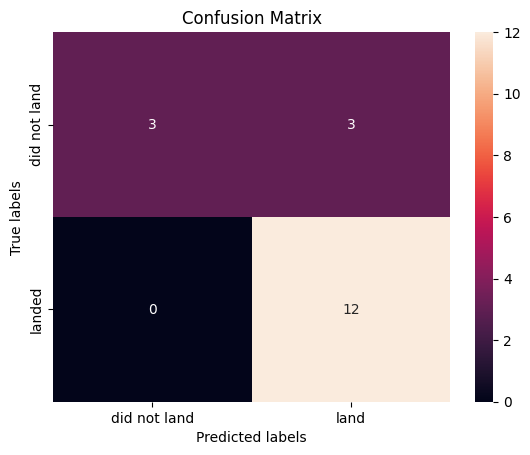

In [103]:
yhat_svm = svm_cv.predict(X_test)
print("SVM Test Accuracy:", accuracy_score(Y_test, yhat_svm))
plot_confusion_matrix(Y_test, yhat_svm)

Tuned hyperparameters: {'criterion': 'gini', 'max_depth': 2}
Accuracy: 0.8178571428571428
DT Test Accuracy: 0.7777777777777778


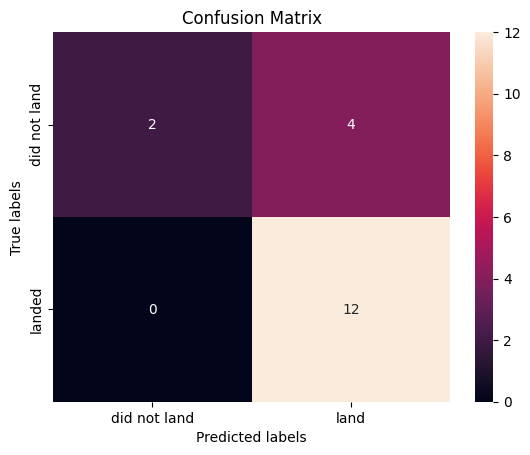

In [104]:
# Predicting and evaluating Decision Tree on test data
parameters = {'max_depth': [2,4,6,8,10],
              'criterion': ['gini','entropy']}

dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, parameters, cv=10)
dt_cv.fit(X_train, Y_train)

print("Tuned hyperparameters:", dt_cv.best_params_)
print("Accuracy:", dt_cv.best_score_)

yhat_dt = dt_cv.predict(X_test)
print("DT Test Accuracy:", accuracy_score(Y_test, yhat_dt))
plot_confusion_matrix(Y_test, yhat_dt)

Tuned hyperparameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Accuracy: 0.8482142857142858
KNN Test Accuracy: 0.8333333333333334


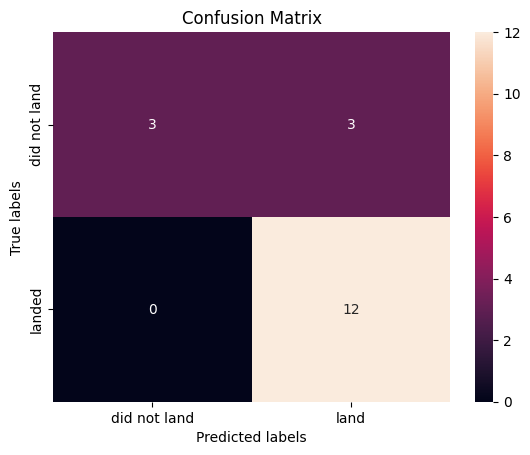

In [105]:
# Predicting and evaluating KNeighbors Classifier on test data
parameters = {'n_neighbors': [2,3,4,5,6,7,8,9,10],
              'algorithm':   ['auto','ball_tree','kd_tree','brute'],
              'p':           [1,2]}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

print("Tuned hyperparameters:", knn_cv.best_params_)
print("Accuracy:", knn_cv.best_score_)

yhat_knn = knn_cv.predict(X_test)
print("KNN Test Accuracy:", accuracy_score(Y_test, yhat_knn))
plot_confusion_matrix(Y_test, yhat_knn)

In [106]:
results = {
    'Logistic Regression': accuracy_score(Y_test, yhat_lr),
    'SVM':                 accuracy_score(Y_test, yhat_svm),
    'Decision Tree':       accuracy_score(Y_test, yhat_dt),
    'KNN':                 accuracy_score(Y_test, yhat_knn)
}

for model, acc in results.items():
    print(f"{model:25s}: {acc:.4f}")

Logistic Regression      : 0.8333
SVM                      : 0.8333
Decision Tree            : 0.7778
KNN                      : 0.8333


## Conclusion

This project successfully predicted Falcon 9 first stage landing outcomes
using machine learning. Among the 4 models tested:

- Logistic Regression, SVM and KNN achieved the highest accuracy of 83.33%
- Decision Tree performed slightly lower at 77.78%
- The results suggest that structured launch data is sufficient
  to predict landing success with reasonable accuracy